# 🔍 PrivAI — Inference Notebook

Script bersih untuk memuat model `best.pt` hasil training dan melakukan prediksi pada gambar, folder, video, maupun webcam.

---

## 📋 Alur Notebook

| Step | Keterangan |
|------|------------|
| 1 | Import & helper functions |
| 2 | Konfigurasi model & kelas |
| 3 | Load model |
| 4 | Prediksi satu gambar |
| 5 | Prediksi batch (folder) |
| 6 | Prediksi video |
| 7 | Prediksi webcam realtime |

> **💡 Cara pakai:** Jalankan Step 1–3 sekali, lalu pilih mode prediksi yang kamu butuhkan (Step 4–7).

## Step 1 — Import & Helper Functions

Sel ini mendefinisikan dua fungsi utama yang dipakai di semua mode prediksi:

- **`draw_detections()`** — menggambar bounding box berlapis (*layered rendering*: dokumen → blur ROI → label wajah/NIK di atas)
- **`print_detections()`** — mencetak ringkasan deteksi ke output sel

In [8]:
import cv2
import torch
import numpy as np
import pandas as pd
from ultralytics import YOLO
from pathlib import Path
from IPython.display import display, Image as IPImage
import time

print(f"PyTorch  : {torch.__version__}")
print(f"CUDA     : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU      : {torch.cuda.get_device_name(0)}")

PyTorch  : 2.11.0+cu126
CUDA     : True
GPU      : NVIDIA GeForce RTX 4050 Laptop GPU


In [9]:
def draw_detections(frame: np.ndarray, results, show_conf=True, blur_classes=None) -> np.ndarray:
    """
    Gambar bounding box + label di atas frame.

    Urutan layer rendering (bawah → atas):
      1. Bbox dokumen (KTP, SIM, Paspor)
      2. Gaussian blur pada ROI kelas sensitif
      3. Label wajah & NIK/Teks di lapisan paling atas

    Args:
        frame        : gambar BGR (numpy array)
        results      : output model.predict()
        show_conf    : tampilkan nilai confidence di label
        blur_classes : list class_id yang ROI-nya di-blur (default: semua kelas)
    """
    annotated = frame.copy()

    if blur_classes is None:
        blur_classes = list(CLASS_COLORS.keys())  # blur semua kelas secara default

    # Pisahkan deteksi ke tiga grup berdasarkan prioritas layer
    priority_low  = []   # dokumen utuh  (KTP=0, SIM=1, Paspor=2)
    priority_mid  = []   # kelas lainnya
    priority_high = []   # sensitif (NIK/Teks=3, Wajah=4)

    for box in results[0].boxes:
        cls_id = int(box.cls[0])
        if cls_id in [3, 4]:
            priority_high.append(box)
        elif cls_id in [0, 1, 2]:
            priority_low.append(box)
        else:
            priority_mid.append(box)

    # Render dari layer bawah ke atas
    for boxes_group in [priority_low, priority_mid, priority_high]:
        for box in boxes_group:
            cls_id        = int(box.cls[0])
            conf          = float(box.conf[0])
            x1, y1, x2, y2 = map(int, box.xyxy[0])

            color    = CLASS_COLORS.get(cls_id, (200, 200, 200))
            cls_name = CLASS_NAMES.get(cls_id, f"cls{cls_id}")
            label    = f"{cls_name} {conf:.2f}" if show_conf else cls_name

            # Gaussian blur pada area ROI jika kelas masuk daftar blur
            if cls_id in blur_classes:
                roi = annotated[y1:y2, x1:x2]
                if roi.shape[0] > 0 and roi.shape[1] > 0:
                    annotated[y1:y2, x1:x2] = cv2.GaussianBlur(roi, (201, 201), 0)
                    # Alternatif black-box — uncomment untuk menggunakan:
                    # annotated[y1:y2, x1:x2] = np.zeros_like(roi)

            # Gambar bounding box
            cv2.rectangle(annotated, (x1, y1), (x2, y2), color, 2)

            # Background label
            (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.55, 1)
            cv2.rectangle(annotated, (x1, y1 - th - 6), (x1 + tw + 4, y1), color, -1)

            # Teks label — hitam jika warna terang, putih jika gelap
            text_col = (0, 0, 0) if sum(color) > 400 else (255, 255, 255)
            cv2.putText(annotated, label, (x1 + 2, y1 - 4),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.55, text_col, 1)

    return annotated


def print_detections(results):
    """Cetak ringkasan deteksi per bounding box."""
    boxes = results[0].boxes
    if len(boxes) == 0:
        print("  — Tidak ada objek terdeteksi")
        return
    for box in boxes:
        cls_id        = int(box.cls[0])
        conf          = float(box.conf[0])
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        name          = CLASS_NAMES.get(cls_id, f"cls{cls_id}")
        print(f"  [{name:10s}]  conf={conf:.3f}  bbox=({x1}, {y1}, {x2}, {y2})")


print("✅ Helper functions siap")

✅ Helper functions siap


## Step 2 — Konfigurasi

**Sesuaikan bagian ini** dengan model dan kelas yang kamu miliki.

### Threshold yang disarankan:
| Parameter | Nilai | Efek jika dinaikkan |
|-----------|-------|--------------------|
| `CONF_THRESHOLD` | 0.35 | Kurangi false positive |
| `IOU_THRESHOLD` | 0.45 | Kurangi bbox ganda |

### Format warna `CLASS_COLORS` — BGR (bukan RGB):
```python
(0, 255, 0)    # Hijau
(255, 165, 0)  # Oranye
(0, 0, 255)    # Merah
(0, 255, 255)  # Kuning
(255, 0, 255)  # Pink
(255, 255, 0)  # Cyan
```

In [10]:
# ─────────────────────────────────────────────
#  ✏️  UBAH SESUAI KEBUTUHANMU
# ─────────────────────────────────────────────

MODEL_PATH = r"D:\PrivAI\runs\privai_v1\weights\best.pt"

# Nama kelas — harus urut sesuai class index di data.yaml
CLASS_NAMES = {
    0: "KTP",
    1: "SIM",
    2: "Paspor",
    3: "NIK/Teks",
    4: "Wajah",
    5: "Plat",
}

# Warna bbox per kelas (BGR)
CLASS_COLORS = {
    0: (0,   255,   0),   # KTP       → hijau
    1: (255, 165,   0),   # SIM       → oranye
    2: (0,     0, 255),   # Paspor    → merah
    3: (0,   255, 255),   # NIK/Teks  → kuning
    4: (255,   0, 255),   # Wajah     → pink
    5: (255, 255,   0),   # Plat      → cyan
}

# Threshold prediksi
CONF_THRESHOLD = 0.35   # naikan → kurangi false positive
IOU_THRESHOLD  = 0.45   # turunkan → kurangi bbox ganda

# ─────────────────────────────────────────────

print("Konfigurasi:")
print(f"  Model path     : {MODEL_PATH}")
print(f"  Conf threshold : {CONF_THRESHOLD}")
print(f"  IoU threshold  : {IOU_THRESHOLD}")
print(f"  Jumlah kelas   : {len(CLASS_NAMES)}")
for idx, name in CLASS_NAMES.items():
    print(f"    [{idx}] {name}")

Konfigurasi:
  Model path     : D:\PrivAI\runs\privai_v1\weights\best.pt
  Conf threshold : 0.35
  IoU threshold  : 0.45
  Jumlah kelas   : 6
    [0] KTP
    [1] SIM
    [2] Paspor
    [3] NIK/Teks
    [4] Wajah
    [5] Plat


## Step 3 — Load Model

Model di-load sekali di sini dan digunakan ulang di semua sel prediksi di bawah.

> **📁 best.pt vs last.pt**
> - `best.pt` → epoch dengan mAP50 tertinggi selama training → **gunakan ini untuk produksi**
> - `last.pt` → epoch terakhir → gunakan hanya untuk melanjutkan training

In [11]:
# Validasi file model ada
model_file = Path(MODEL_PATH)
if not model_file.exists():
    raise FileNotFoundError(
        f"Model tidak ditemukan: {MODEL_PATH}\n"
        "Pastikan training sudah selesai dan path MODEL_PATH sudah benar."
    )

# Load model
model  = YOLO(MODEL_PATH)
device = 0 if torch.cuda.is_available() else "cpu"

print("=" * 45)
print("  MODEL BERHASIL DIMUAT")
print("=" * 45)
print(f"  File    : {model_file.name}")
print(f"  Ukuran  : {model_file.stat().st_size / 1e6:.1f} MB")
print(f"  Device  : {'GPU — ' + torch.cuda.get_device_name(0) if device == 0 else 'CPU'}")
print(f"  Kelas   : {model.names}")
print("=" * 45)
print("\n✅ Model siap digunakan. Lanjut ke Step 4–7.")

  MODEL BERHASIL DIMUAT
  File    : best.pt
  Ukuran  : 5.5 MB
  Device  : GPU — NVIDIA GeForce RTX 4050 Laptop GPU
  Kelas   : {0: 'KTP', 1: 'SIM', 2: 'Paspor', 3: 'NIK_Teks', 4: 'Wajah', 5: 'Plat_Nomor'}

✅ Model siap digunakan. Lanjut ke Step 4–7.


## Step 4 — Prediksi Satu Gambar

Mode paling sederhana: baca satu file gambar → prediksi → tampilkan hasil inline di notebook.

Hasil annotasi juga otomatis disimpan di folder yang sama dengan suffix `_result`.

Gambar   : D:\PrivAI\test_images\face_asli_0.jpg
Resolusi : 1024x1385 px
Waktu    : 293.1 ms
Deteksi  : 1 objek

  [Wajah     ]  conf=0.861  bbox=(444, 316, 583, 476)


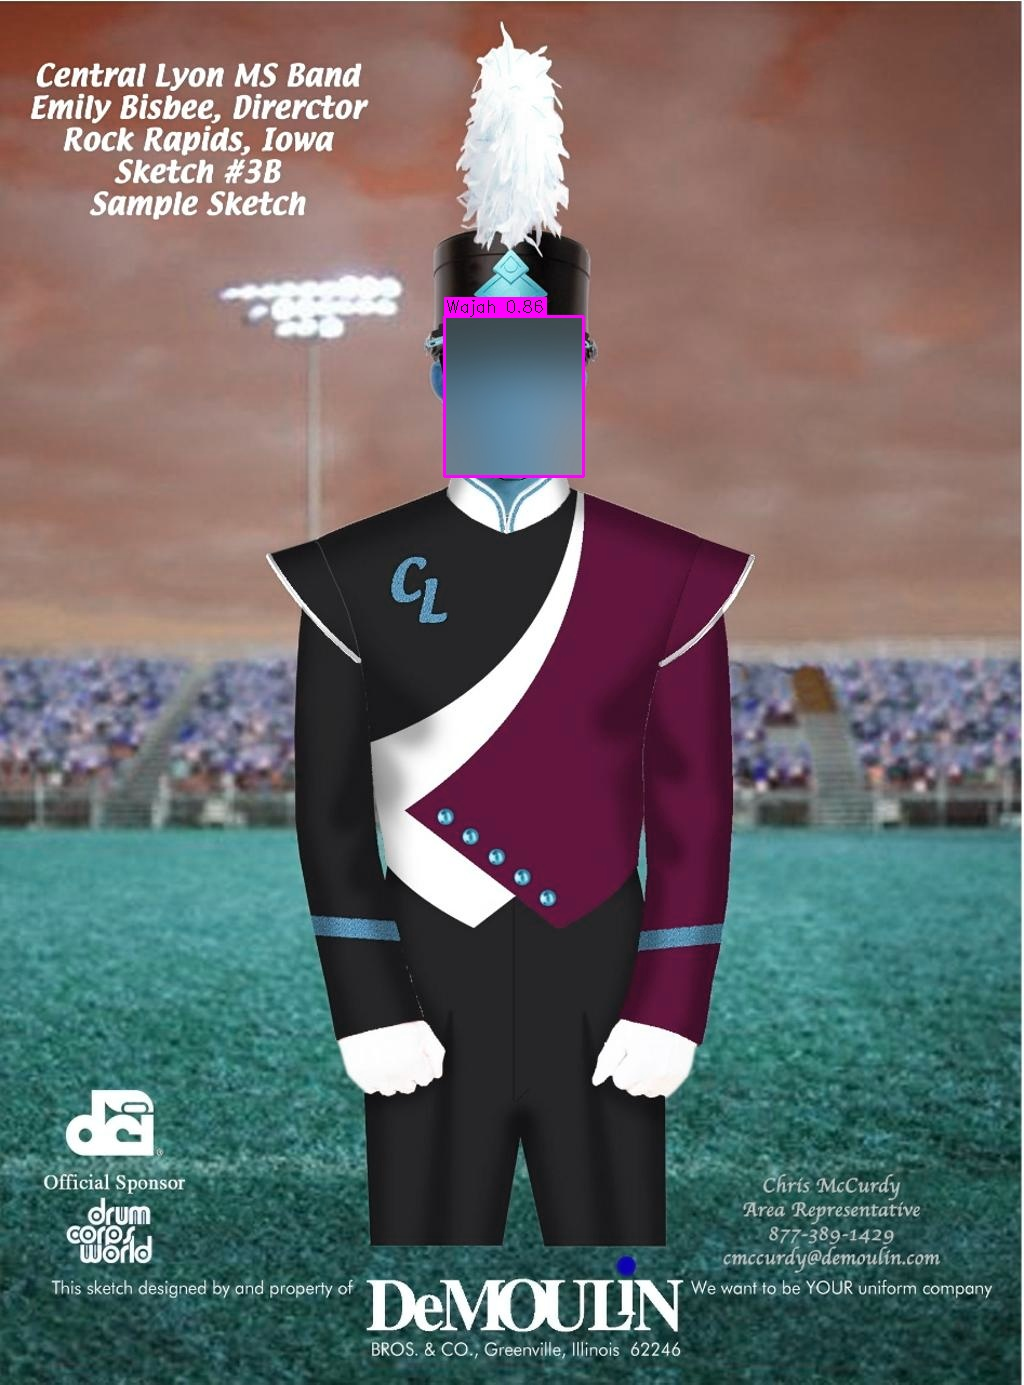


💾 Disimpan: D:\PrivAI\test_images\face_asli_0_result.jpg


In [ ]:
# ✏️  Ganti dengan path gambar yang ingin diuji
IMAGE_PATH = r"D:\PrivAI\test_images\sample.jpg"

# ─────────────────────────────────────────────

img = cv2.imread(IMAGE_PATH)
if img is None:
    raise FileNotFoundError(f"Gambar tidak ditemukan: {IMAGE_PATH}")

# Inferensi
t0      = time.perf_counter()
results = model.predict(img, conf=CONF_THRESHOLD, iou=IOU_THRESHOLD, verbose=False)
ms      = (time.perf_counter() - t0) * 1000

# Ringkasan
print(f"Gambar   : {IMAGE_PATH}")
print(f"Resolusi : {img.shape[1]}x{img.shape[0]} px")
print(f"Waktu    : {ms:.1f} ms")
print(f"Deteksi  : {len(results[0].boxes)} objek")
print()
print_detections(results)

# Gambar bbox + blur
annotated = draw_detections(img, results)

# Tampilkan inline di notebook
rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)
display(IPImage(data=cv2.imencode(".jpg", rgb)[1].tobytes()))

# Simpan ke file
out_path = str(Path(IMAGE_PATH).with_stem(Path(IMAGE_PATH).stem + "_result"))
cv2.imwrite(out_path, annotated)
print(f"\n💾 Disimpan: {out_path}")

### 4b — Kustomisasi Blur

Kamu bisa mengontrol kelas mana yang ROI-nya di-blur, atau menonaktifkan blur sama sekali.

```python
# Blur semua kelas (default)
draw_detections(img, results)

# Blur hanya NIK/Teks (3) dan Wajah (4)
draw_detections(img, results, blur_classes=[3, 4])

# Tanpa blur sama sekali — hanya bbox
draw_detections(img, results, blur_classes=[])
```

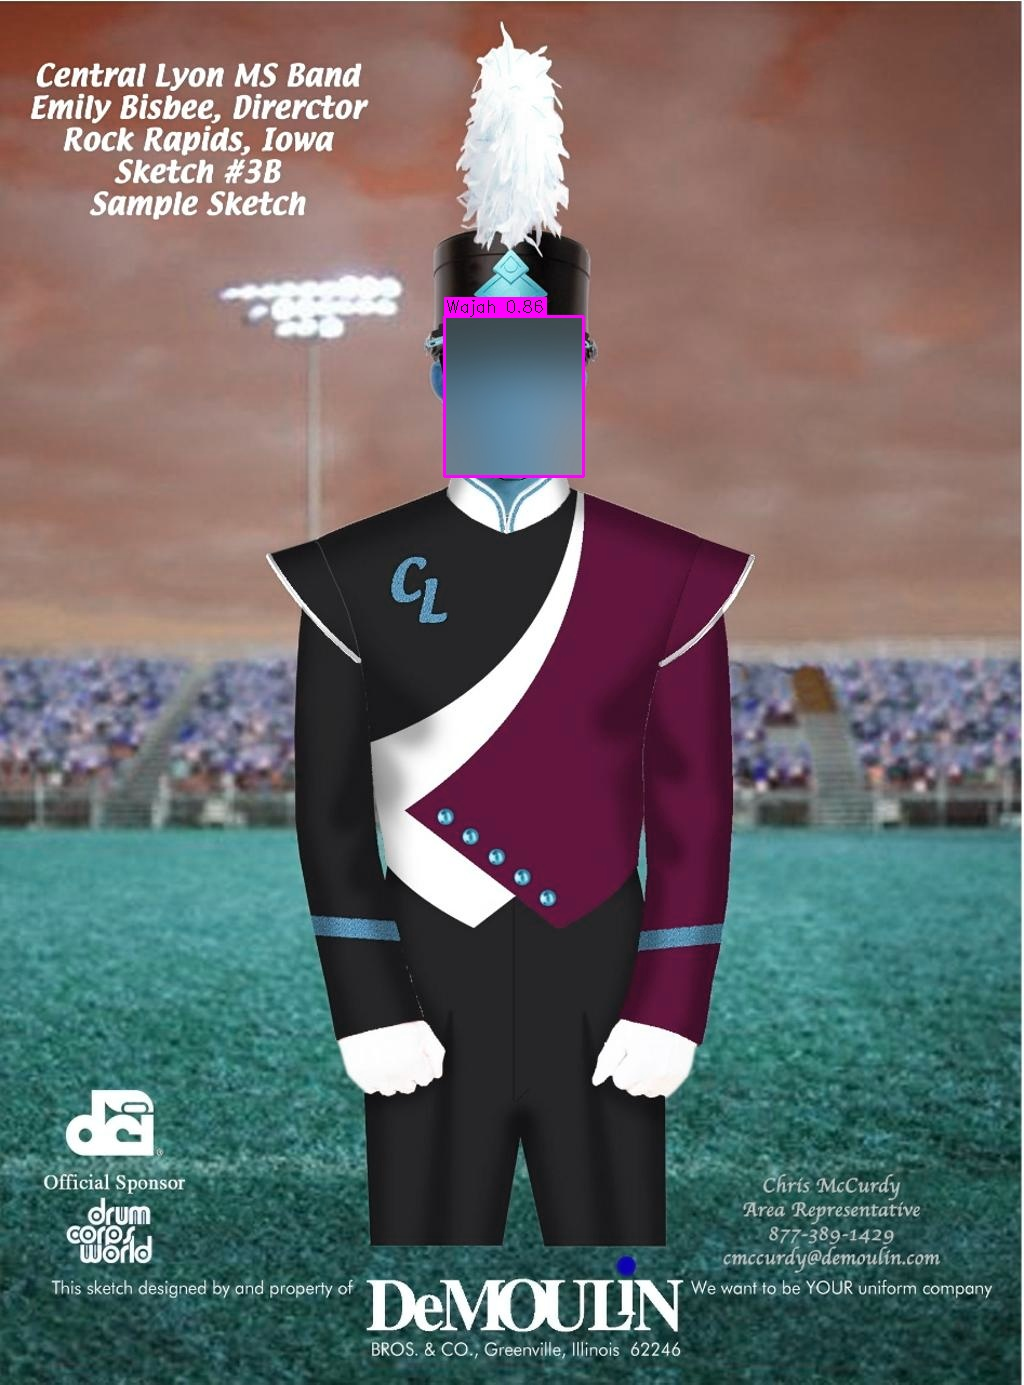

↑ Blur hanya pada NIK/Teks dan Wajah


In [13]:
# Contoh: blur hanya NIK/Teks dan Wajah, kelas lain hanya bbox biasa
annotated_custom = draw_detections(img, results, blur_classes=[3, 4])

rgb_custom = cv2.cvtColor(annotated_custom, cv2.COLOR_BGR2RGB)
display(IPImage(data=cv2.imencode(".jpg", rgb_custom)[1].tobytes()))
print("↑ Blur hanya pada NIK/Teks dan Wajah")

## Step 5 — Prediksi Batch (Folder)

Proses seluruh gambar `.jpg` dan `.png` dalam satu folder sekaligus.

Output:
- Gambar hasil anotasi disimpan di subfolder `results/`
- Tabel ringkasan semua deteksi dapat diekspor ke CSV

In [14]:
# ✏️  Ganti dengan path folder gambar
FOLDER_PATH  = r"D:\PrivAI\test_images"
SAVE_OUTPUT  = True     # simpan gambar hasil anotasi ke subfolder results/
EXPORT_CSV   = True     # ekspor tabel deteksi ke results/detections.csv

# ─────────────────────────────────────────────

folder = Path(FOLDER_PATH)
images = sorted(list(folder.glob("*.jpg")) + list(folder.glob("*.png")))

if not images:
    print(f"⚠️  Tidak ada gambar .jpg/.png ditemukan di: {FOLDER_PATH}")
else:
    print(f"Folder  : {FOLDER_PATH}")
    print(f"Gambar  : {len(images)} file")

    out_folder = folder / "results"
    if SAVE_OUTPUT:
        out_folder.mkdir(exist_ok=True)

    records    = []  # untuk CSV
    total_ms   = 0
    total_det  = 0

    for i, img_path in enumerate(images):
        img = cv2.imread(str(img_path))
        if img is None:
            print(f"  ⚠️  Gagal membaca: {img_path.name}")
            continue

        t0      = time.perf_counter()
        results = model.predict(img, conf=CONF_THRESHOLD, iou=IOU_THRESHOLD, verbose=False)
        ms      = (time.perf_counter() - t0) * 1000

        total_ms  += ms
        n_det      = len(results[0].boxes)
        total_det += n_det

        # Kumpulkan record per deteksi untuk CSV
        for box in results[0].boxes:
            cls_id        = int(box.cls[0])
            conf          = float(box.conf[0])
            x1,y1,x2,y2  = map(int, box.xyxy[0])
            records.append({
                "file"    : img_path.name,
                "class_id": cls_id,
                "class"   : CLASS_NAMES.get(cls_id, f"cls{cls_id}"),
                "conf"    : round(conf, 4),
                "x1"      : x1, "y1": y1, "x2": x2, "y2": y2,
                "width"   : x2 - x1,
                "height"  : y2 - y1,
            })

        # Simpan gambar hasil anotasi
        if SAVE_OUTPUT:
            annotated = draw_detections(img, results)
            cv2.imwrite(str(out_folder / img_path.name), annotated)

        # Progress
        bar = "█" * int((i + 1) / len(images) * 20)
        print(f"  [{bar:<20s}] {i+1:4d}/{len(images)}  {img_path.name:35s}  {ms:6.1f}ms  {n_det} det",
              end="\r" if i < len(images) - 1 else "\n")

    # Ringkasan
    avg_ms = total_ms / len(images)
    print(f"\n{'='*50}")
    print(f"  Total gambar   : {len(images)}")
    print(f"  Total deteksi  : {total_det}")
    print(f"  Rata-rata /img : {avg_ms:.1f} ms  ({1000/avg_ms:.1f} FPS)")
    if SAVE_OUTPUT:
        print(f"  Hasil anotasi  : {out_folder}")
    print(f"{'='*50}")

    # Ekspor CSV
    if EXPORT_CSV and records:
        df = pd.DataFrame(records)
        csv_path = out_folder / "detections.csv"
        df.to_csv(csv_path, index=False)
        print(f"\n📊 CSV tersimpan: {csv_path}")
        display(df.head(10))

Folder  : D:\PrivAI\test_images
Gambar  : 22 file
  [████████████████████]   22/22  face_asli_8.jpg                        37.8ms  0 det

  Total gambar   : 22
  Total deteksi  : 37
  Rata-rata /img : 36.0 ms  (27.8 FPS)
  Hasil anotasi  : D:\PrivAI\test_images\results

📊 CSV tersimpan: D:\PrivAI\test_images\results\detections.csv


,file,class_id,class,conf,x1,y1,x2,y2,width,height
0,face_asli_0.jpg,4,Wajah,0.8610,444,316,583,476,139,160
1,face_asli_10.jpg,4,Wajah,0.8815,271,312,565,735,294,423
2,face_asli_11.jpg,4,Wajah,0.8122,595,800,653,879,58,79
3,face_asli_11.jpg,4,Wajah,0.7191,385,491,609,829,224,338
4,face_asli_12.jpg,4,Wajah,0.8819,397,270,470,345,73,75
5,face_asli_12.jpg,4,Wajah,0.8452,706,215,782,297,76,82
6,face_asli_12.jpg,4,Wajah,0.8387,232,244,307,328,75,84
7,face_asli_12.jpg,4,Wajah,0.8264,86,224,158,306,72,82
8,face_asli_12.jpg,4,Wajah,0.7873,813,206,883,280,70,74
9,face_asli_12.jpg,4,Wajah,0.7544,563,223,625,289,62,66


## Step 6 — Prediksi Video

Proses file video frame per frame. Hasil video anotasi disimpan dengan suffix `_result.mp4`.

> **⌨️ Kontrol saat jendela terbuka:**
> - Tekan **Q** untuk berhenti lebih awal
> - Progress FPS ditampilkan setiap 30 frame

> **💡 Catatan:** Sel ini membuka jendela OpenCV terpisah. Jika menjalankan di **remote server / WSL**, ubah `SHOW_PREVIEW = False`.

In [15]:
# ✏️  Ganti dengan path video
VIDEO_PATH   = r"D:\PrivAI\test_videos\sample.mp4"
SAVE_OUTPUT  = True    # simpan video hasil anotasi
SHOW_PREVIEW = True    # tampilkan preview (nonaktifkan jika remote/server)

# ─────────────────────────────────────────────

cap = cv2.VideoCapture(VIDEO_PATH)
if not cap.isOpened():
    raise IOError(f"Gagal membuka video: {VIDEO_PATH}")

fps_src = cap.get(cv2.CAP_PROP_FPS)
w       = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h       = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total   = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
print(f"Video    : {VIDEO_PATH}")
print(f"Resolusi : {w}x{h} @ {fps_src:.1f} fps — {total} frame")

writer = None
if SAVE_OUTPUT:
    out_path = str(Path(VIDEO_PATH).with_stem(Path(VIDEO_PATH).stem + "_result"))
    writer   = cv2.VideoWriter(out_path, cv2.VideoWriter_fourcc(*"mp4v"), fps_src, (w, h))

print("\nMemproses video... (tekan Q di jendela preview untuk berhenti)\n")

frame_n   = 0
fps_list  = []
t_start   = time.perf_counter()

while True:
    ret, frame = cap.read()
    if not ret:
        break

    t0      = time.perf_counter()
    results = model.predict(frame, conf=CONF_THRESHOLD, iou=IOU_THRESHOLD, verbose=False)
    ms      = (time.perf_counter() - t0) * 1000

    fps_list.append(1000 / ms)
    if len(fps_list) > 30:
        fps_list.pop(0)
    fps = sum(fps_list) / len(fps_list)

    annotated = draw_detections(frame, results)

    # HUD — FPS + jumlah deteksi
    n_det = len(results[0].boxes)
    cv2.putText(annotated, f"FPS: {fps:.1f}  Det: {n_det}",
                (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)

    if writer:
        writer.write(annotated)

    if SHOW_PREVIEW:
        cv2.imshow("PrivAI — Video", annotated)
        if cv2.waitKey(1) & 0xFF == ord("q"):
            print("Dihentikan oleh pengguna.")
            break

    frame_n += 1
    if frame_n % 30 == 0:
        elapsed = time.perf_counter() - t_start
        pct     = frame_n / total * 100
        print(f"  Frame {frame_n:5d}/{total}  ({pct:5.1f}%)  avg {fps:.1f} FPS", end="\r")

cap.release()
if writer:
    writer.release()
cv2.destroyAllWindows()

elapsed = time.perf_counter() - t_start
print(f"\n\n✅ Selesai — {frame_n} frame dalam {elapsed:.1f} detik ({frame_n/elapsed:.1f} FPS rata-rata)")
if SAVE_OUTPUT:
    print(f"💾 Video disimpan: {out_path}")

OSError: Gagal membuka video: D:\PrivAI\test_videos\sample.mp4

## Step 7 — Webcam Realtime

Inferensi langsung dari kamera laptop/eksternal dengan tampilan FPS dan jumlah deteksi live.

> **⌨️ Kontrol saat berjalan:**
> | Tombol | Aksi |
> |--------|------|
> | **Q** | Keluar dari webcam |
> | **S** | Simpan screenshot frame saat itu |
> | **B** | Toggle blur ON/OFF |

> **💡 Catatan:** `camera_id=0` adalah kamera default. Ganti ke `1`, `2`, dst. jika ada kamera eksternal.

In [ ]:
CAMERA_ID       = 0       # 0 = kamera default, 1/2/dst = kamera eksternal
CAPTURE_WIDTH   = 1280    # resolusi capture
CAPTURE_HEIGHT  = 720
SCREENSHOT_DIR  = r"D:\PrivAI\screenshots"  # folder simpan screenshot

# ─────────────────────────────────────────────

Path(SCREENSHOT_DIR).mkdir(parents=True, exist_ok=True)

cap = cv2.VideoCapture(CAMERA_ID)
if not cap.isOpened():
    raise IOError(f"Gagal membuka kamera ID {CAMERA_ID}")

cap.set(cv2.CAP_PROP_FRAME_WIDTH,  CAPTURE_WIDTH)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, CAPTURE_HEIGHT)

print("Webcam aktif")
print("  Q → keluar  |  S → screenshot  |  B → toggle blur")

fps_list     = []
screenshot_n = 0
blur_on      = True    # blur aktif secara default

while True:
    ret, frame = cap.read()
    if not ret:
        print("Frame tidak terbaca — kamera mungkin terputus.")
        break

    t0      = time.perf_counter()
    results = model.predict(frame, conf=CONF_THRESHOLD, iou=IOU_THRESHOLD,
                             verbose=False, stream=False)
    ms      = (time.perf_counter() - t0) * 1000

    fps_list.append(1000 / ms)
    if len(fps_list) > 30:
        fps_list.pop(0)
    fps = sum(fps_list) / len(fps_list)

    # blur_classes=[] untuk matikan blur sementara
    blur_cls  = None if blur_on else []
    annotated = draw_detections(frame, results, blur_classes=blur_cls)

    # HUD
    n_det      = len(results[0].boxes)
    blur_label = "BLUR: ON" if blur_on else "BLUR: OFF"
    cv2.putText(annotated, f"FPS: {fps:.1f}  Det: {n_det}  {blur_label}",
                (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)

    cv2.imshow("PrivAI — Webcam (Q=keluar, S=screenshot, B=toggle blur)", annotated)

    key = cv2.waitKey(1) & 0xFF
    if key == ord("q"):
        break
    elif key == ord("s"):
        fname = str(Path(SCREENSHOT_DIR) / f"screenshot_{screenshot_n:03d}.jpg")
        cv2.imwrite(fname, annotated)
        print(f"📸 Screenshot: {fname}")
        screenshot_n += 1
    elif key == ord("b"):
        blur_on = not blur_on
        print(f"   Blur {'ON' if blur_on else 'OFF'}")

cap.release()
cv2.destroyAllWindows()
print(f"\n✅ Webcam ditutup. {screenshot_n} screenshot disimpan di {SCREENSHOT_DIR}")

OSError: Gagal membuka kamera ID 0